# Earnings call sentiment + forward returns

End-to-end pipeline:

1. Parse Motley Fool transcripts → ticker, date, quarter, prepared remarks, Q&A
2. Score both sections with FinBERT (`ProsusAI/finbert`)
3. Pull adjusted close prices via yfinance, compute t+1 / t+3 / t+5 returns
4. Save a clean CSV and print a validation summary

All the heavy lifting lives in `earnings_pipeline.py` (in the same folder as this notebook). The cells below import its functions and walk through each step so you can inspect intermediate output.

## 0. Install dependencies (one-time)

Skip this cell if you already have these installed.

In [1]:
%pip install --quiet transformers torch yfinance pandas


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Imports and configuration

In [ ]:
from pathlib import Path
import pandas as pd

# Transcripts live under raw_text/<TICKER>/ (e.g. raw_text/AAPL/, raw_text/AMZN/).
# discover_transcripts() uses rglob so all .txt files are found recursively.
TRANSCRIPTS_DIR = Path.cwd() / "raw_text"
OUTPUT_CSV      = Path.cwd() / "earnings_sentiment_returns.csv"

# Make pandas show full text in DataFrames so we can eyeball parsed sections.
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 140)

import earnings_pipeline as ep
print("transcripts dir:", TRANSCRIPTS_DIR)

## 2. Parse every transcript

`discover_transcripts` walks the folder recursively, skipping `README.txt`. `parse_transcript_file` extracts the five fields per file.

In [3]:
files = ep.discover_transcripts(TRANSCRIPTS_DIR)
print(f"found {len(files)} transcript files")

parsed = [ep.parse_transcript_file(f) for f in files]

parse_df = pd.DataFrame([
    {
        "ticker": p.ticker,
        "call_date": p.call_date,
        "quarter": p.quarter,
        "prepared_chars": len(p.prepared_remarks),
        "qa_chars": len(p.qa_section),
        "file": Path(p.source_path).name,
    }
    for p in parsed
])
parse_df.sort_values(["ticker", "call_date"]).reset_index(drop=True)

found 35 transcript files


,ticker,call_date,quarter,prepared_chars,qa_chars,file
0,AAPL,2024-10-31,Q4 2024,19485,29281,AAPL_Q4_2024.txt
1,AAPL,2025-01-30,Q1 2025,19059,29906,AAPL_Q1_2025.txt
2,AAPL,2025-07-31,Q3 2025,19374,25557,AAPL_Q3_2025.txt
3,AAPL,2025-10-30,Q4 2025,20406,24122,AAPL_Q4_2025.txt
4,AAPL,2026-01-29,Q1 2026,18557,29247,AAPL_Q1_2026.txt
5,AMZN,2024-04-30,Q1 2024,25438,26382,AMZN_Q1_2024.txt
6,AMZN,2024-08-01,Q2 2024,23220,24768,AMZN_Q2_2024.txt
7,AMZN,2025-02-06,Q4 2024,25488,23858,AMZN_Q4_2024.txt
8,AMZN,2025-10-30,Q3 2025,23911,21671,AMZN_Q3_2025.txt
9,AMZN,2026-02-05,Q4 2025,26484,26736,AMZN_Q4_2025.txt


In [4]:
# Sanity-check: peek at the first 400 characters of one transcript's split.
sample = parsed[0]
print(f"=== {sample.ticker} {sample.call_date} ({sample.quarter}) ===")
print("\n--- prepared remarks (first 400 chars) ---")
print(sample.prepared_remarks[:400])
print("\n--- Q&A (first 400 chars) ---")
print(sample.qa_section[:400])

=== AAPL 2025-01-30 (Q1 2025) ===

--- prepared remarks (first 400 chars) ---
Suhasini Chandramouli
--
Director, Investor Relations
Good afternoon, and welcome to the Apple Q1 fiscal year 2025 earnings conference call. My name is Suhasini Chandramouli, Director of investor relations. Today's call is being recorded. Speaking first today are Apple CEO, Tim Cook; and he'll be followed by CFO, Kevan Parekh.
After that, we'll open the call to questions from analysts. Please note

--- Q&A (first 400 chars) ---
Operator
Certainly. We will go ahead and take our first question from Erik Woodring with Morgan Stanley. Please go ahead.
Erik Woodring
--
Analyst
Great, guys. Thanks so much for taking my questions. You know, Tim, in your prepared remarks, you had noted that iPhone 16 models are selling better in markets where Apple Intelligence is available. And I'm just wondering if you could double-click on th


## 3. Score sentiment with FinBERT

First run downloads `ProsusAI/finbert` (~440 MB) from huggingface.co and caches it. Each section is tokenised once and scored in 510-token chunks; chunk softmax probabilities are averaged before argmax, so the label and confidence reflect the entire section, not just its first 512 tokens.

On CPU, expect ~3–6 seconds per section. The whole corpus runs in a couple of minutes.

In [5]:
# Warm the model up once so the timing on the loop below is steady.
_ = ep.score_section("We delivered record revenue and our outlook is very strong.")
print("FinBERT loaded")

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT loaded


In [6]:
from time import perf_counter

rows = []
t0 = perf_counter()
for i, p in enumerate(parsed, 1):
    prep_label, prep_score = ep.score_section(p.prepared_remarks)
    qa_label, qa_score    = ep.score_section(p.qa_section)
    rows.append({
        "ticker": p.ticker,
        "call_date": p.call_date,
        "quarter": p.quarter,
        "prepared_sentiment": prep_label,
        "prepared_score": round(prep_score, 4) if prep_score is not None else None,
        "qa_sentiment": qa_label,
        "qa_score": round(qa_score, 4) if qa_score is not None else None,
    })
    print(f"[{i:>2}/{len(parsed)}] {p.ticker:<5} {p.call_date} "
          f"prep={prep_label}({prep_score:.2f}) qa={qa_label}({qa_score:.2f})")
print(f"\ndone in {perf_counter()-t0:.1f}s")

sentiment_df = pd.DataFrame(rows)
sentiment_df.head()

Token indices sequence length is longer than the specified maximum sequence length for this model (3993 > 512). Running this sequence through the model will result in indexing errors


[ 1/35] AAPL  2025-01-30 prep=positive(0.58) qa=neutral(0.70)


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

[ 2/35] AAPL  2026-01-29 prep=positive(0.62) qa=neutral(0.71)
[ 3/35] AAPL  2025-07-31 prep=positive(0.66) qa=neutral(0.79)
[ 4/35] AAPL  2024-10-31 prep=positive(0.54) qa=neutral(0.80)
[ 5/35] AAPL  2025-10-30 prep=positive(0.69) qa=neutral(0.73)
[ 6/35] AMZN  2024-04-30 prep=positive(0.58) qa=neutral(0.76)
[ 7/35] AMZN  2024-08-01 prep=positive(0.53) qa=neutral(0.76)
[ 8/35] AMZN  2025-10-30 prep=positive(0.59) qa=neutral(0.75)
[ 9/35] AMZN  2025-02-06 prep=positive(0.55) qa=neutral(0.83)
[10/35] AMZN  2026-02-05 prep=positive(0.54) qa=neutral(0.76)
[11/35] GOOGL 2025-07-23 prep=positive(0.73) qa=neutral(0.68)
[12/35] GOOGL 2025-10-29 prep=positive(0.65) qa=neutral(0.65)
[13/35] GOOGL 2025-02-04 prep=positive(0.60) qa=neutral(0.66)
[14/35] GOOGL 2026-02-04 prep=positive(0.76) qa=neutral(0.72)
[15/35] META  2026-04-23 prep=positive(0.55) qa=neutral(0.54)
[16/35] META  2024-10-30 prep=positive(0.63) qa=neutral(0.76)
[17/35] META  2025-10-29 prep=positive(0.72) qa=neutral(0.79)
[18/35] 

,ticker,call_date,quarter,prepared_sentiment,prepared_score,qa_sentiment,qa_score
0,AAPL,2025-01-30,Q1 2025,positive,0.5806,neutral,0.6971
1,AAPL,2026-01-29,Q1 2026,positive,0.6167,neutral,0.7133
2,AAPL,2025-07-31,Q3 2025,positive,0.6633,neutral,0.7911
3,AAPL,2024-10-31,Q4 2024,positive,0.5448,neutral,0.7966
4,AAPL,2025-10-30,Q4 2025,positive,0.6931,neutral,0.7283


## 4. Forward returns from yfinance

We pull a 5-year history per ticker (auto-adjusted for splits/dividends), cache it, and compute `close[t+N] / close[t] - 1` for N ∈ {1, 3, 5} trading days. `t` is the first trading day on or after the call date — so a Friday-night call rolls to the following Monday.

In [7]:
ret_rows = []
for p in parsed:
    rets = ep.forward_returns(p.ticker, p.call_date)
    ret_rows.append({"ticker": p.ticker, "call_date": p.call_date, **rets})

returns_df = pd.DataFrame(ret_rows)
returns_df.head(10)

,ticker,call_date,ret_1d,ret_3d,ret_5d
0,AAPL,2025-01-30,-0.006692,-0.020161,-0.018393
1,AAPL,2026-01-29,0.004646,0.043364,0.068259
2,AAPL,2025-07-31,-0.025004,-0.022402,0.060028
3,AAPL,2024-10-31,-0.013280,-0.010889,0.006950
4,AAPL,2025-10-30,-0.003795,-0.005011,-0.006006
5,AMZN,2024-04-30,0.022857,0.064057,0.078629
6,AMZN,2024-08-01,-0.087847,-0.120280,-0.099256
7,AMZN,2025-10-30,0.095845,0.118729,0.090550
8,AMZN,2025-02-06,-0.040531,-0.025416,-0.035423
9,AMZN,2026-02-05,-0.055548,-0.070636,-0.103687


## 5. Combine and save the final CSV

In [8]:
df = sentiment_df.merge(returns_df, on=["ticker", "call_date"], how="left")
out_cols = [
    "ticker", "call_date", "quarter",
    "prepared_sentiment", "prepared_score",
    "qa_sentiment", "qa_score",
    "ret_1d", "ret_3d", "ret_5d",
]
df = df[out_cols].sort_values(["ticker", "call_date"]).reset_index(drop=True)
df.to_csv(OUTPUT_CSV, index=False)
print(f"wrote {OUTPUT_CSV}")
df

wrote /Users/shesirui/Desktop/earnings_transcripts/earnings_sentiment_returns.csv


,ticker,call_date,quarter,prepared_sentiment,prepared_score,qa_sentiment,qa_score,ret_1d,ret_3d,ret_5d
0,AAPL,2024-10-31,Q4 2024,positive,0.5448,neutral,0.7966,-0.013280,-0.010889,0.006950
1,AAPL,2025-01-30,Q1 2025,positive,0.5806,neutral,0.6971,-0.006692,-0.020161,-0.018393
2,AAPL,2025-07-31,Q3 2025,positive,0.6633,neutral,0.7911,-0.025004,-0.022402,0.060028
3,AAPL,2025-10-30,Q4 2025,positive,0.6931,neutral,0.7283,-0.003795,-0.005011,-0.006006
4,AAPL,2026-01-29,Q1 2026,positive,0.6167,neutral,0.7133,0.004646,0.043364,0.068259
5,AMZN,2024-04-30,Q1 2024,positive,0.5801,neutral,0.7589,0.022857,0.064057,0.078629
6,AMZN,2024-08-01,Q2 2024,positive,0.5267,neutral,0.7641,-0.087847,-0.120280,-0.099256
7,AMZN,2025-02-06,Q4 2024,positive,0.5485,neutral,0.8319,-0.040531,-0.025416,-0.035423
8,AMZN,2025-10-30,Q3 2025,positive,0.5925,neutral,0.7521,0.095845,0.118729,0.090550
9,AMZN,2026-02-05,Q4 2025,positive,0.5356,neutral,0.7593,-0.055548,-0.070636,-0.103687


## 6. Validation summary

Counts, missing data, sentiment distribution — the same checks the standalone script prints at the end.

In [9]:
print(f"Total transcripts parsed: {len(df)}")

missing = df[df[["ret_1d", "ret_3d", "ret_5d"]].isna().any(axis=1)]
print(f"\nTranscripts with at least one missing forward return: {len(missing)}")
if len(missing):
    print(missing[["ticker", "call_date", "ret_1d", "ret_3d", "ret_5d"]].to_string(index=False))

print("\nPrepared-remarks sentiment distribution:")
print(df["prepared_sentiment"].value_counts().to_string())
print("\nQ&A sentiment distribution:")
print(df["qa_sentiment"].value_counts().to_string())

Total transcripts parsed: 35

Transcripts with at least one missing forward return: 1
ticker  call_date   ret_1d   ret_3d  ret_5d
  META 2026-04-23 0.024092 0.018494     NaN

Prepared-remarks sentiment distribution:
prepared_sentiment
positive    31
neutral      4

Q&A sentiment distribution:
qa_sentiment
neutral    35


## 7. Optional — quick exploratory plots

Two charts: sentiment counts side-by-side, and a scatter of prepared-remarks score vs. 5-day forward return. Skip this section if you don't have matplotlib.

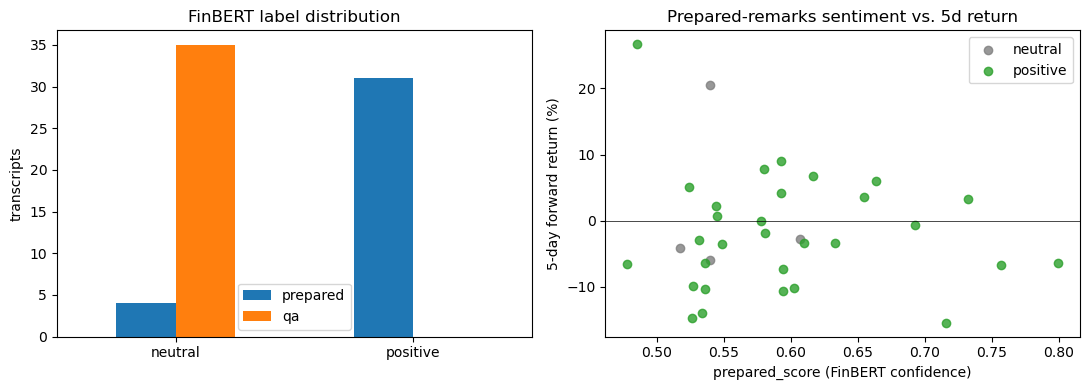

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Sentiment distributions
counts = pd.DataFrame({
    "prepared": df["prepared_sentiment"].value_counts(),
    "qa":       df["qa_sentiment"].value_counts(),
}).fillna(0)
counts.plot.bar(ax=axes[0])
axes[0].set_title("FinBERT label distribution")
axes[0].set_ylabel("transcripts")
axes[0].tick_params(axis="x", rotation=0)

# Sentiment vs. 5-day return
color_map = {"positive": "tab:green", "neutral": "tab:gray", "negative": "tab:red"}
for label, sub in df.dropna(subset=["ret_5d"]).groupby("prepared_sentiment"):
    axes[1].scatter(sub["prepared_score"], sub["ret_5d"] * 100,
                    label=label, color=color_map.get(label, "black"), alpha=0.8)
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_xlabel("prepared_score (FinBERT confidence)")
axes[1].set_ylabel("5-day forward return (%)")
axes[1].set_title("Prepared-remarks sentiment vs. 5d return")
axes[1].legend()

plt.tight_layout()
plt.show()